# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [51]:
STUDENT_NAME = "Nguyễn Hoàng Nam"  # TODO: Họ và tên
STUDENT_ID = "25122030"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Hoàng Nam (25122030)


In [52]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\ADMIN\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [53]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [54]:
# TODO N1
# shifted_logits = ...
# exp_logits = ...
# class_probabilities = ...
# predicted_classes = ...
# confidence_scores = ...

row_max = np.max(logits, axis=1, keepdims=True)

shifted_logits = logits - row_max

exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [55]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [56]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [57]:
# TODO N2
# train_feature_mean = ...
# train_feature_std = ...
# X_train_scaled = ...
# X_val_scaled = ...

train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [58]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [59]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [60]:
# TODO N3
# correct_mask = ...
# high_confidence_mask = ...
# review_mask = ...
# review_indices = ...

correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [61]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [62]:
# TODO N4
# normalized_batch = ...
# augmented_batch = ...
# augmented_batch[0, 0, 0, 0] = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe trong bộ data.
2. Dấu "?".
3. Thể hiện mức độ đánh giá rủi ro bảo hiểm của xe từ -3 tới 3 với giá trị càng lớn thì rủi ro càng cao

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [63]:
# TODO D1
# raw_df = ...
# raw_shape = ...
# raw_missing_marker_count = ...

raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [64]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [65]:
# TODO D2
# df_clean = ...
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...

df_clean = raw_df.replace('?', np.nan).copy()

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

missing_by_column = df_clean.isna().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

Không nên điền tất cả các thuộc tính thiếu bằng cùng một giá trị vì mỗi cột dữ liệu sở hữu ý nghĩa đơn vị, phân phối và đơn vị hoàn toàn khác nhau, nếu làm vậy sẽ tạo nhiễu và bóp méo phân phối tự nhiên.

Riêng đối với cột giá tiền price, phương án tối ưu là loại bỏ các dòng thiếu dữ liệu do đây thường là biến mục tiêu quan trọng nhất, việc điền giá trị giả định có thể dẫn đến sai số nghiêm trọng cho mô hình dự báo.

Đối với normalized_losses, việc thiếu hụt lượng lớn dữ liệu gây ra rủi ro: nếu xóa hàng sẽ làm giảm quy mô tập dữ liệu có ý nghĩa, còn nếu điền giá trị thay thế lại có nguy cơ làm giảm độ biến động và sai lệch các phân tích về rủi ro bảo hiểm.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [66]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [67]:
# TODO D3
# analysis_df = ...
# X_auto = ...
# auto_feature_mean = ...
# auto_feature_std = ...
# X_auto_scaled = ...

analysis_df = df_clean[AUTO_FEATURES].dropna().copy()

X_auto = analysis_df.values.astype(np.float64)

auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [68]:
# TODO D4
# price_index = ...
# price_z = ...
# price_outlier_mask = ...
# price_outliers = ...

price_index = AUTO_FEATURES.index('price')

price_z = X_auto_scaled[:, price_index]

price_outlier_mask = np.abs(price_z) > 2

price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [69]:
# TODO D5
# engine_price_corr = ...
# price_by_body_style = ...

engine_index = AUTO_FEATURES.index('engine_size')
engine_size_arr = X_auto[:, engine_index]
price_arr = X_auto[:, price_index]

engine_price_corr = np.corrcoef(engine_size_arr, price_arr)[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

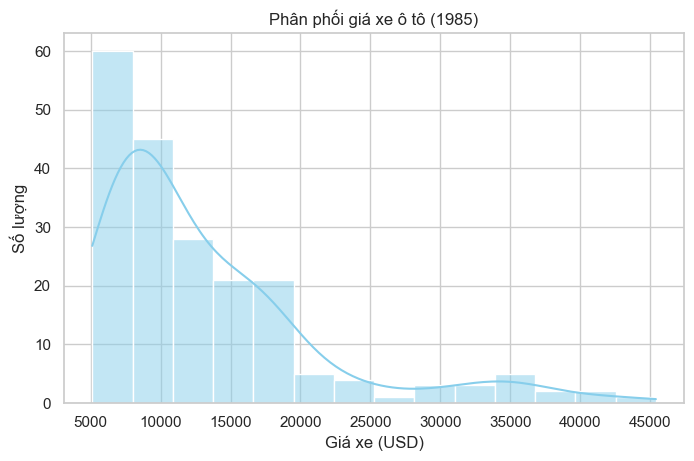

In [70]:
# TODO M2.1: histogram/KDE của price

sns.histplot(data=df_clean, x='price', kde=True, color='skyblue')
plt.title('Phân phối giá xe ô tô (1985)')
plt.xlabel('Giá xe (USD)')
plt.ylabel('Số lượng')
plt.show()

**Nhận xét:** Phân phối giá xe bị lệch phải rất nhiều. Phần lớn các mẫu xe tập trung ở phân khúc giá rẻ đến tầm trung từ 5000 đến 15,000 đô, trong khi chỉ có một số ít xe hạng sang có giá vượt trên 30000 đô.

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23028\2167928953.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')


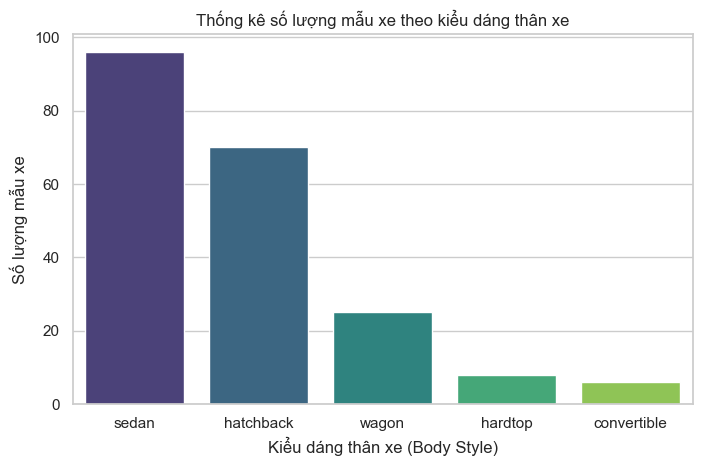

In [71]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, palette='viridis')
plt.title('Thống kê số lượng mẫu xe theo kiểu dáng thân xe')
plt.xlabel('Kiểu dáng thân xe (Body Style)')
plt.ylabel('Số lượng mẫu xe')
plt.show()

**Nhận xét:** Bộ dữ liệu mất cân bằng khá lớn về kiểu dáng. Hai dòng xe sedan và hatchback chiếm đại đa số số lượng mẫu xe, trong khi dòng convertible và hardtop xuất hiện với tần suất rất thấp.

## M2.3 Price khác nhau theo body style ra sao?

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23028\2226623030.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')


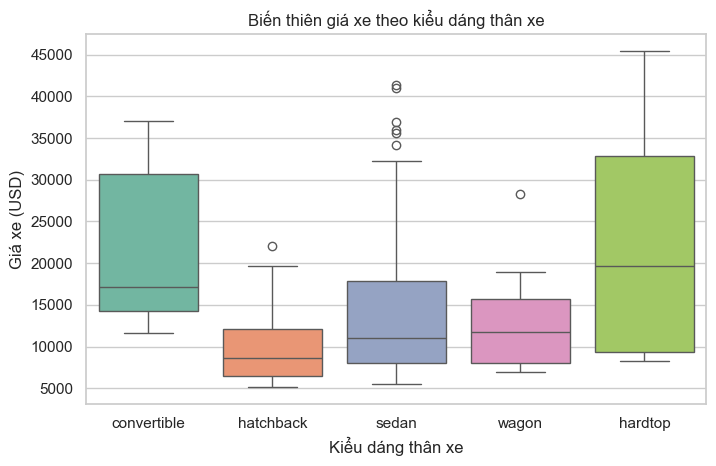

In [72]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price', palette='Set2')
plt.title('Biến thiên giá xe theo kiểu dáng thân xe')
plt.xlabel('Kiểu dáng thân xe')
plt.ylabel('Giá xe (USD)')
plt.show()

**Nhận xét:** Các dòng xe hardtop và convertible có giá median cao hơn hẳn các dòng xe khác. Ngược lại, hatchback là dòng xe có phân khúc giá dễ tiếp cận nhất nhưng lại có khá nhiều biến động và các điểm outliers.

## M2.4 Engine size liên quan thế nào tới price?

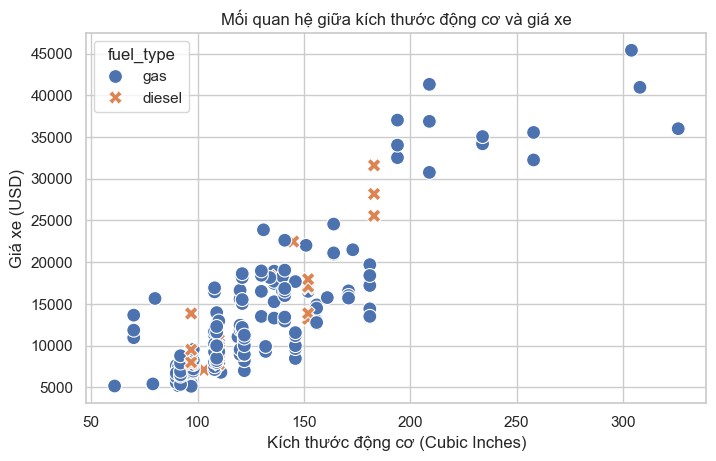

In [73]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', style='fuel_type', s=100)
plt.title('Mối quan hệ giữa kích thước động cơ và giá xe')
plt.xlabel('Kích thước động cơ (Cubic Inches)')
plt.ylabel('Giá xe (USD)')
plt.show()

**Nhận xét:** Có một mối tương quan tuyến tính thuận mạnh mẽ giữa kích thước động cơ và giá xe. Xe có dung tích xi lanh lớn hơn thường có giá thành đắt hơn rất nhiều, xu hướng này đúng cho cả xe xăng lẫn chạy dầu.

## M2.5 Các feature numeric tương quan ra sao?

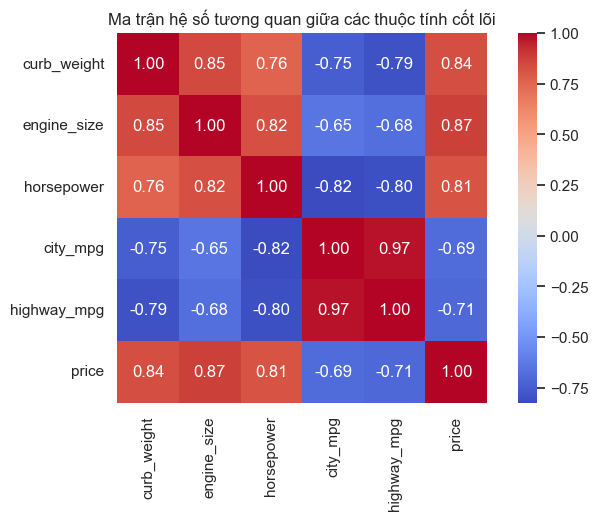

In [74]:
# TODO M2.5: correlation heatmap
# Tính ma trận tương quan cho 6 biến cốt lõi
corr_matrix = analysis_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Ma trận hệ số tương quan giữa các thuộc tính cốt lõi')
plt.show()

**Nhận xét:** curb_weight, engine_size và horsepower có tương quan thuận cực kỳ mạnh với price (r > 0.8). Mặt khác, các biến đo lường mức tiết kiệm nhiên liệu (city_mpg, highway_mpg) có tương quan nghịch rất mạnh với giá xe và kích thước xe, chứng tỏ xe càng to, đắt tiền thì càng tiêu tốn nhiên liệu.

## M2.6 Biểu đồ tự chọn

Công suất động cơ (horsepower) có ảnh hưởng khác nhau tới hiệu suất tiêu hao nhiên liệu trên đường cao tốc (highway_mpg) giữa hai cấu hình nạp khí tự nhiên (std) và tăng áp (turbo) không?

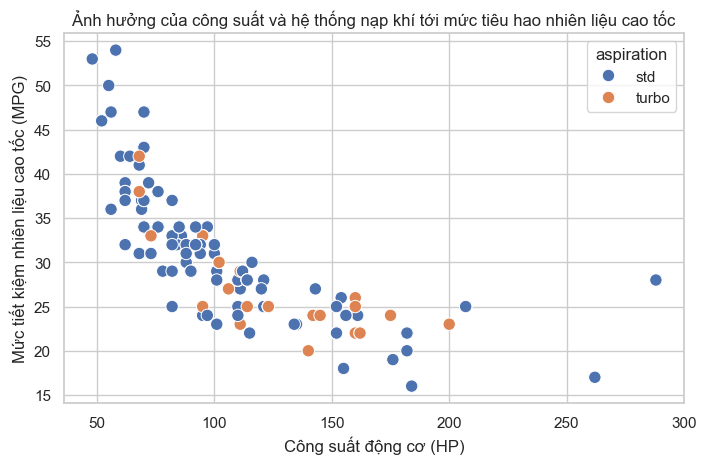

In [75]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=df_clean, x='horsepower', y='highway_mpg', hue='aspiration', s=80)
plt.title('Ảnh hưởng của công suất và hệ thống nạp khí tới mức tiêu hao nhiên liệu cao tốc')
plt.xlabel('Công suất động cơ (HP)')
plt.ylabel('Mức tiết kiệm nhiên liệu cao tốc (MPG)')
plt.show()

**Nhận xét:** Công suất càng cao thì số dặm đi được trên mỗi gallon xăng càng giảm. Đáng chú ý hơn là cấu hình tăng áp (turbo) thường gom cụm ở vùng công suất từ trung bình đến cao nhưng lại giữ được mức MPG tương đương hoặc chỉ giảm nhẹ so với các dòng nạp khí tự nhiên (std) với cùng mức công suất.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Phát hiện chính: Đầu tiên, kích thước động cơ và khối lượng xe là hai yếu tố chủ chốt quyết định giá sản phẩm ($r_{engine\_size \times price} \approx 0.87$). Thứ hai, các dòng xe đắt tiền nhất thường ở trong nhóm thể thao hoặc mui trần (hardtop/convertible) mặc dù chỉ chiếm tỉ trọng nhỏ trong dataset. Cuối cùng, có một sự tương quan âm rất mạnh giữa horsepower với highway_mpg ($r \approx -0.705$) - những dòng xe có hiệu năng vận hành cao, mạnh mẽ luôn phải đánh đổi bằng việc tiêu thụ lượng xăng lớn hơn đáng kể.

Hạn chế của bộ dữ liệu:
- Dữ liệu thu thập từ năm 1985 nên các thông số về giá cả, tiêu chuẩn tiêu hao nhiên liệu không còn phản ánh đúng thị trường ô tô hiện đại.
- Tỉ lệ missing dữ liệu ở một số cột khá cao, điển hình như normalized_losses (thiếu hơn 20%), gây khó khăn cho việc phân tích rủi ro toàn diện.

Correlation không đồng nghĩa causation: correlation âm giữa price và city_mpg (xe đắt tiền thì MPG thấp). Tuy nhiên, giá cao không phải là nguyên nhân trực tiếp làm xe tốn xăng hơn. Nguyên nhân gốc rễ là do xe đắt tiền thường trang bị động cơ dung tích lớn, cấu trúc phức tạp và trọng lượng nặng để tối ưu hiệu năng, và chính các yếu tố kỹ thuật này mới trực tiếp làm giảm chỉ số MPG.

Câu hỏi nên phân tích tiếp: Làm thế nào để xây dựng một mô hình ML sử dụng curb_weight, engine_size kết hợp với  drive_wheels nhằm dự đoán giá xe mà không chịu ảnh hưởng quá nhiều bởi outliers?
